# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [173]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [174]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN

SYMBOL = "TSLA"

df = pd.read_csv(RAW_DIR/f"{safe_symbol(SYMBOL)}.csv")
df['date'] = pd.to_datetime(df['date'])
df.loc[df['volume']==0] = np.nan

In [175]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [176]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
return_1     = close.pct_change(1)
return_5     = close.pct_change(5)
log_return_1 = np.log(close/close.shift(1))

df['return_1']     = return_1
df['return_5']     = return_5
df['log_return_1'] = log_return_1

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [177]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = df['close'].rolling(window=20).mean()
df['sma_50']      = df['close'].rolling(window=50).mean()
df['sma_200']     = df['close'].rolling(window=200).mean()
df['sma_ratio_20'] = (df['close']/df['sma_20'])-1
df['sma_ratio_50'] = (df['close']/df['sma_50'])-1

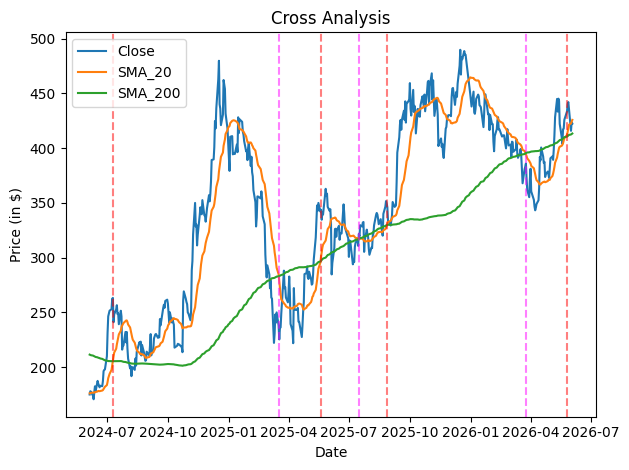

In [178]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.loc[df['date'] > pd.Timestamp.now()-pd.DateOffset(years=2)]
cross  = recent.loc[(recent['sma_20']-recent['sma_200'])*(recent['sma_20'].shift(1)-recent['sma_200'].shift(1))<0]
golden = cross.loc[cross['sma_20']-cross['sma_200']>0,'date']
death  = cross.loc[cross['sma_20']-cross['sma_200']<0,'date']


# Plot Graph
plt.plot(recent['date'], recent['close'],label="Close")
plt.plot(recent['date'], recent['sma_20'],label="SMA_20")
plt.plot(recent['date'], recent['sma_200'], label="SMA_200")
for date in golden:
    plt.axvline(date, linestyle="--", color="red", alpha=0.5)
for date in death:
    plt.axvline(date, linestyle="--", color="magenta", alpha=0.5)
plt.title("Cross Analysis")
plt.xlabel("Date"); plt.ylabel("Price (in $)")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [179]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df['ema_12']       = df['close'].ewm(span=12, adjust=False).mean()
df['ema_20']       = df['close'].ewm(span=20, adjust=False).mean()
df['ema_26']       = df['close'].ewm(span=26, adjust=False).mean()
df['ema_ratio_20'] = (df['close']/df['ema_20'])-1

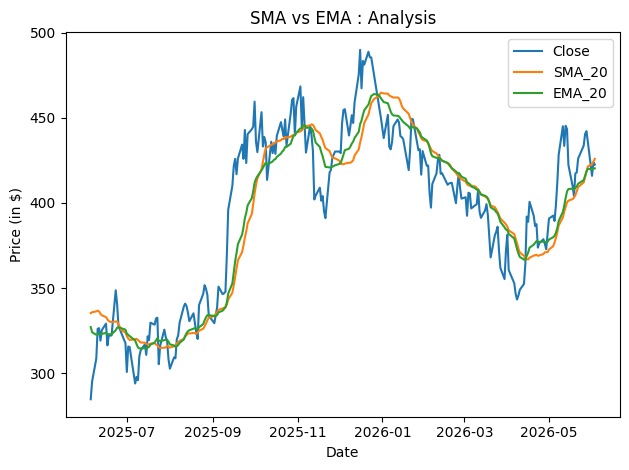

In [180]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent_ema = df.loc[df['date']>pd.Timestamp.now()-pd.DateOffset(days=365)]

# Plot Graph
plt.plot(recent_ema['date'],recent_ema['close'],label="Close")
plt.plot(recent_ema['date'],recent_ema['sma_20'],label="SMA_20")
plt.plot(recent_ema['date'],recent_ema['ema_20'],label="EMA_20")
plt.title("SMA vs EMA : Analysis")
plt.xlabel("Date"); plt.ylabel("Price (in $)")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [181]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

# Window
n = 14

delta    =  df['close']-df['close'].shift(1)
gain     =  delta.copy(); gain.loc[gain<0]=0
loss     =  delta.copy(); loss.loc[loss>0]=0; loss.loc[loss<0] = -loss
avg_gain =  gain.ewm(com=n-1, adjust=False).mean()
avg_loss =  loss.ewm(com=n-1, adjust=False).mean()
rs       =  avg_gain/avg_loss
df['rsi_14'] = 1 - (1/(1+rs))       # Normalised

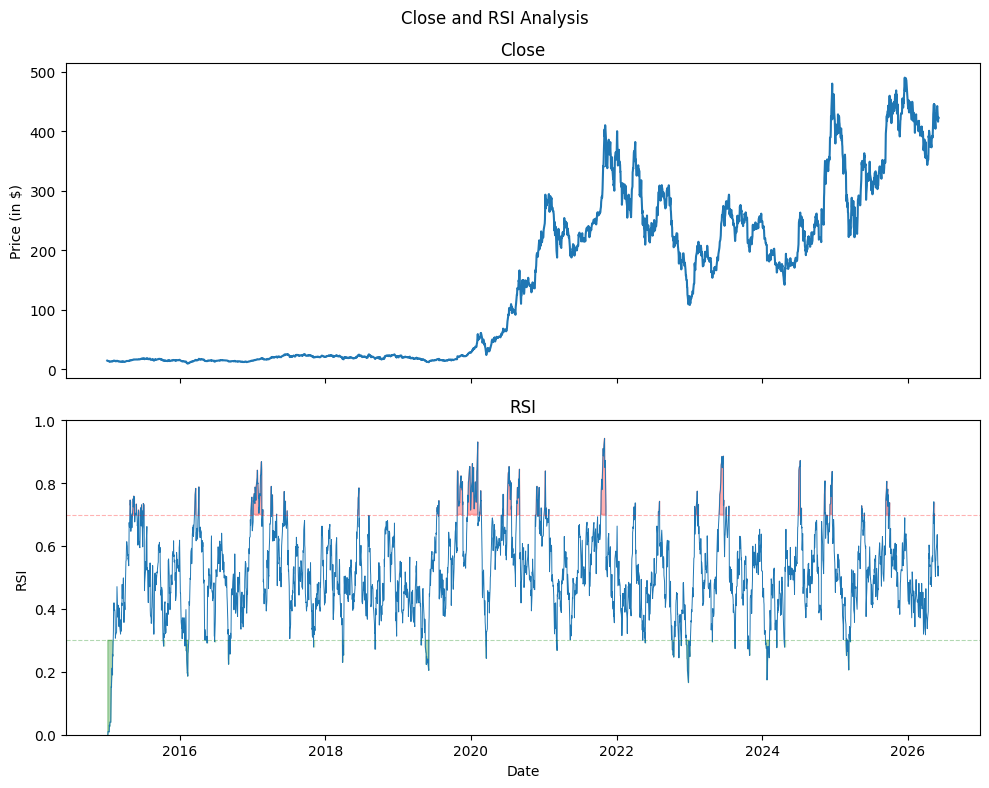

In [182]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green

fig, axes = plt.subplots(2,1, figsize=(10,8),sharex=True)

axes[0].plot(df['date'],df['close'])
axes[1].plot(df['date'],df['rsi_14'],linewidth=0.7)
plt.suptitle("Close and RSI Analysis")

axes[1].set_xlabel("Date")
axes[0].set_ylabel("Price (in $)")
axes[1].set_ylabel("RSI")
axes[0].set_title("Close")
axes[1].set_title("RSI")
axes[1].set_ylim(0,1)

axes[1].axhline(0.7, color='red', alpha=0.3, linestyle='--', linewidth=0.8)
axes[1].axhline(0.3, color='green', alpha=0.3, linestyle='--', linewidth=0.8)


axes[1].fill_between(df['date'], df['rsi_14'], 0.7,
                     where=(df['rsi_14'] >= 0.7), color='red',   alpha=0.3)
axes[1].fill_between(df['date'], df['rsi_14'], 0.3,
                     where=(df['rsi_14'] <= 0.3), color='green', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [183]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd']-df['macd_signal']

<BarContainer object of 2871 artists>

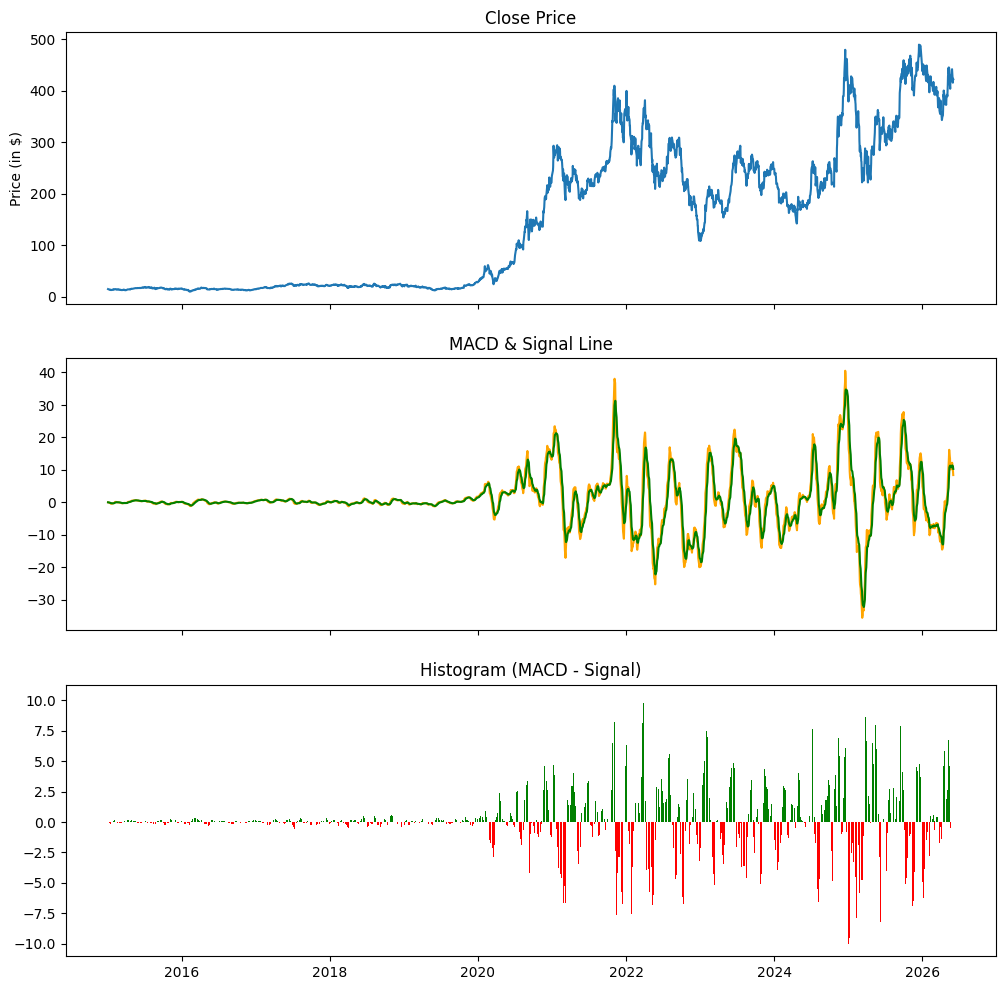

In [184]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
fig, axes = plt.subplots(3,1,figsize=(12,12), sharex=True)

axes[0].plot(df['date'],df['close'])
axes[0].set_title("Close")
axes[0].set_ylabel("Price (in $)")

axes[1].plot(df['date'],df['macd'],color="orange")
axes[1].plot(df['date'],df['macd_signal'],color="green")
axes[0].set_title("Close Price")
axes[1].set_title("MACD & Signal Line")
axes[2].set_title("Histogram (MACD - Signal)")

axes[2].bar(df['date'],df['macd_hist'],width=1.2, color=np.where(df['macd_hist'] >= 0, 'green', 'red'))

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [185]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = df['close'].rolling(window=20).std()
df['bb_upper'] = df['sma_20'] + 2*rolling_std
df['bb_lower'] = df['sma_20'] - 2*rolling_std
df['bb_width'] = (df['bb_upper']-df['bb_lower'])/df['close']
df['bb_pct_b'] = (df['close']-df['bb_lower'])/(df['bb_upper']-df['bb_lower'])   # clip to [0, 1] optional but useful

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [186]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = ((df['close']-df['close'].shift(5))/df['close'].shift(5))*100
df['roc_10'] = ((df['close']-df['close'].shift(10))/df['close'].shift(10))*100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [187]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close      = df['close'].shift(1)
true_range      = pd.concat([df['high']-df['low'],np.abs(df['high']-prev_close),np.abs(df['low']-prev_close)],axis=1).max(axis=1)
df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
df['atr_ratio'] = df['atr_14']/df['close']

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [188]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].rolling(window=14).min()
highest_high = df['high'].rolling(window=14).max()
df['stoch_k'] = ((df['close']-lowest_low)/(highest_high-lowest_low))
df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()

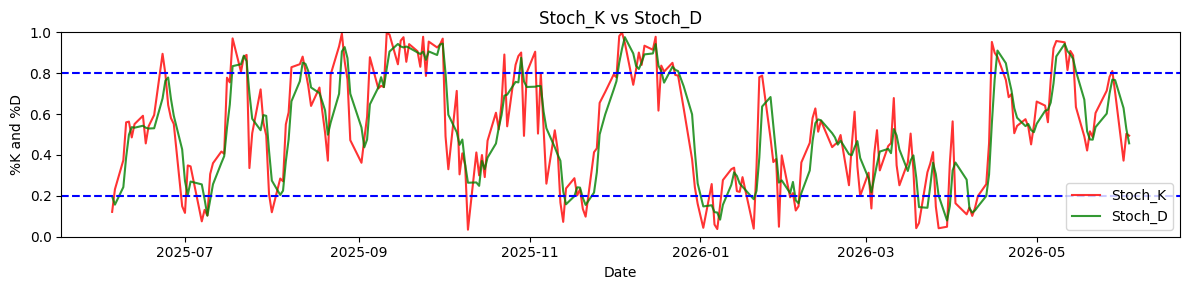

In [189]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent_stoch = df[['date','stoch_k','stoch_d']].loc[df['date']>pd.Timestamp.now()-pd.DateOffset(days=365)]

# Plotting
plt.figure(figsize=(12,3))
plt.title("Stoch_K vs Stoch_D")
plt.plot(recent_stoch['date'],recent_stoch['stoch_k'],color='red',alpha=0.8, label="Stoch_K")
plt.plot(recent_stoch['date'],recent_stoch['stoch_d'],color='green',alpha=0.8, label="Stoch_D")
plt.axhline(0.8, color='blue', linestyle='--'); plt.axhline(0.2, color='blue', linestyle='--')
plt.ylim(0,1)
plt.xlabel("Date"); plt.ylabel("%K and %D"); plt.legend(); plt.tight_layout(); plt.show()

## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [190]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(close.diff())
df['obv']       = (df['volume']*direction).cumsum()
df['obv_change']= (df['obv']-df['obv'].shift(1))/np.abs(df['obv'].shift(1))

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [191]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (df['high']+df['low']+df['close'])/3
tp_vol          = typical_price * df['volume']
df['vwap']      = (tp_vol.rolling(window=20).sum())/(df['volume'].rolling(window=20).sum())
df['vwap_ratio'] = df['close']/df['vwap'] -1

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [192]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
]

In [193]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = df['close'].shift(-1)/df['close'] - 1
df['target_direction'] = np.where(df['future_return']>0, 1, 0)


required = FEATURE_COLUMNS + ['future_return', 'target_direction']
df_clean = df[required].dropna(axis=0)

out_path = PROCESSED_DIR/f"{safe_symbol(SYMBOL)}_features.csv"
df_clean.to_csv(out_path)
print(f"Out Path : {out_path}\nShape : {df_clean.shape}")
df_clean[required].describe().round(4)

Out Path : /Users/tusharmeena/Documents/IITB/Stock Trading with LSTM and RL/SOC-Stock-Trading-With-LSTM-And-RL/Week2/data/processed/TSLA_features.csv
Shape : (2821, 20)


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000,2821.0000
mean,0.0019,0.0097,0.0012,0.0139,0.0352,0.0113,0.5253,0.9805,0.9649,0.9656,1.9443,0.2366,0.5360,0.0453,0.5414,0.5412,-0.1363,0.0135,0.0019,0.5183
std,0.0362,0.0836,0.0361,0.0950,0.1564,0.0796,0.1322,8.3217,7.8324,8.3578,12.1122,0.1425,0.3285,0.0162,0.3058,0.2863,5.3184,0.0884,0.0362,0.4998
min,-0.2106,-0.4305,-0.2365,-0.4632,-0.4498,-0.4115,0.1656,-35.5832,-32.2386,-43.0459,-51.8052,0.0483,-0.2721,0.0209,0.0003,0.0075,-221.1243,-0.4527,-0.2106,0.0000
25%,-0.0168,-0.0390,-0.0170,-0.0407,-0.0651,-0.0332,0.4347,-0.6347,-0.5724,-3.9033,-5.5199,0.1421,0.2707,0.0350,0.2628,0.2723,-0.0138,-0.0395,-0.0168,0.0000
50%,0.0013,0.0055,0.0013,0.0081,0.0172,0.0069,0.5150,0.1514,0.1515,0.5510,1.2472,0.1972,0.5477,0.0421,0.5676,0.5701,0.0035,0.0091,0.0013,1.0000
75%,0.0196,0.0514,0.0194,0.0589,0.1186,0.0510,0.6121,3.0209,2.8757,5.1394,8.0098,0.2965,0.7998,0.0523,0.8233,0.8079,0.0258,0.0596,0.0196,1.0000
max,0.2269,0.5648,0.2045,0.5502,0.9526,0.4948,0.9420,40.5386,34.7566,56.4756,65.8833,1.6452,1.3400,0.1921,1.0000,0.9906,36.6010,0.4635,0.2269,1.0000


In [202]:
# Custom method to combine the calculations of All Indicators

def compute_indicator(SYMBOL):
    # TODO 0.1 — Load a symbol from RAW_DIR
    # Use 'SPY' or any symbol you downloaded in Notebook 1.
    # - parse 'date' as datetime index, sort ascending
    # - ensure columns: open, high, low, close, volume (all lowercase)
    # - replace 0-volume rows with NaN

    df = pd.read_csv(RAW_DIR/f"{safe_symbol(SYMBOL)}.csv")
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['volume']!=0]

    # Run this after TODO 0.1 is complete

    close  = df['close']
    high   = df['high']
    low    = df['low']
    volume = df['volume']

    # TODO 0.2 — Compute base return features needed for the model
    # These are not indicators, but inputs the LSTM will use directly.
    #
    return_1     = close.pct_change(1)
    return_5     = close.pct_change(5)
    log_return_1 = np.log(close/close.shift(1))

    df['return_1']     = return_1
    df['return_5']     = return_5
    df['log_return_1'] = log_return_1

    # TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
    #             and sma_ratio_20, sma_ratio_50

    df['sma_20']      = df['close'].rolling(window=20).mean()
    df['sma_50']      = df['close'].rolling(window=50).mean()
    df['sma_200']     = df['close'].rolling(window=200).mean()
    df['sma_ratio_20'] = (df['close']/df['sma_20'])-1
    df['sma_ratio_50'] = (df['close']/df['sma_50'])-1

    # TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

    df['ema_12']       = df['close'].ewm(span=12, adjust=False).mean()
    df['ema_20']       = df['close'].ewm(span=20, adjust=False).mean()
    df['ema_26']       = df['close'].ewm(span=26, adjust=False).mean()
    df['ema_ratio_20'] = (df['close']/df['ema_20'])-1
        
    # TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
    # Use Wilder smoothing: ewm(com=n-1, adjust=False)

    # Window
    n = 14

    delta    =  df['close']-df['close'].shift(1)
    gain     =  delta.copy(); gain.loc[gain<0]=0
    loss     =  delta.copy(); loss.loc[loss>0]=0; loss.loc[loss<0] = -loss
    avg_gain =  gain.ewm(com=n-1, adjust=False).mean()
    avg_loss =  loss.ewm(com=n-1, adjust=False).mean()
    rs       =  avg_gain/avg_loss
    df['rsi_14'] = 1 - (1/(1+rs))       # Normalised

    # TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

    df['macd']        = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist']   = df['macd']-df['macd_signal']

    # TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

    rolling_std    = df['close'].rolling(window=20).std()
    df['bb_upper'] = df['sma_20'] + 2*rolling_std
    df['bb_lower'] = df['sma_20'] - 2*rolling_std
    df['bb_width'] = (df['bb_upper']-df['bb_lower'])/df['close']
    df['bb_pct_b'] = (df['close']-df['bb_lower'])/(df['bb_upper']-df['bb_lower'])   # clip to [0, 1] optional but useful

    # TODO 6 — Compute roc_5 and roc_10

    df['roc_5']  = ((df['close']-df['close'].shift(5))/df['close'].shift(5))*100
    df['roc_10'] = ((df['close']-df['close'].shift(10))/df['close'].shift(10))*100

    # TODO 7 — Compute true_range, atr_14, atr_ratio
    # Use Wilder smoothing (ewm with com=13, adjust=False)

    prev_close      = df['close'].shift(1)
    true_range      = pd.concat([df['high']-df['low'],np.abs(df['high']-prev_close),np.abs(df['low']-prev_close)],axis=1).max(axis=1)
    df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
    df['atr_ratio'] = df['atr_14']/df['close']

    # TODO 8.1 — Compute stoch_k and stoch_d

    lowest_low   = df['low'].rolling(window=14).min()
    highest_high = df['high'].rolling(window=14).max()
    df['stoch_k'] = ((df['close']-lowest_low)/(highest_high-lowest_low))
    df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()

    # TODO 9 — Compute obv and obv_change
    # np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction
    direction       = np.sign(close.diff())
    df['obv']       = (df['volume']*direction).cumsum()
    df['obv_change']= (df['obv']-df['obv'].shift(1))/np.abs(df['obv'].shift(1))

    # TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

    typical_price   = (df['high']+df['low']+df['close'])/3
    tp_vol          = typical_price * df['volume']
    df['vwap']      = (tp_vol.rolling(window=20).sum())/(df['volume'].rolling(window=20).sum())
    df['vwap_ratio'] = df['close']/df['vwap'] -1

    FEATURE_COLUMNS = [
        'return_1', 'return_5', 'log_return_1',
        'sma_ratio_20', 'sma_ratio_50',
        'ema_ratio_20',
        'rsi_14',
        'macd', 'macd_signal',
        'roc_5', 'roc_10',
        'bb_width', 'bb_pct_b',
        'atr_ratio',
        'stoch_k', 'stoch_d',
        'obv_change',
        'vwap_ratio',
    ]

    # TODO 11.1 — Add target columns, clean, and save
    # 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
    # 'target_direction' = 1 if future_return > 0, else 0
    #
    # Then:
    #   1. Replace inf / -inf with NaN
    #   2. Drop rows where ANY required column is NaN
    #   3. Reset index so 'date' becomes a regular column again
    #   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
    #   5. Print the output path and shape; show .describe() of required columns

    df['future_return']    = df['close'].shift(-1)/df['close'] - 1
    df['target_direction'] = np.where(df['future_return']>0, 1, 0)


    required = ['date']+FEATURE_COLUMNS + ['future_return', 'target_direction']
    df_clean = df[required].dropna(axis=0)

    return df_clean



In [203]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in RAW_DIR.iterdir():
    sym = str(csv_path).split('/')[-1][:-4]
    try:
        raw       = pd.read_csv(csv_path)
        # ... compute all indicators on raw ...
        processed = compute_indicator(sym)
        out_path = PROCESSED_DIR/f"{sym}_features.csv"
        processed.to_csv(out_path, index=False)
        drop_pct = (((raw.shape[0] - processed.shape[0])/raw.shape[0])*100).__round__(2)
        summary.append({'symbol':sym,'rows_raw':raw.shape[0],'rows_processed':processed.shape[0],'drop_pct':drop_pct})
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

,symbol,rows_raw,rows_processed,drop_pct
0,INFY_NS,2820,2765,1.95
1,ETH_USD,3129,3079,1.60
2,TCS_NS,2820,2765,1.95
3,BTC_USD,4172,4122,1.20
4,MSFT,2871,2821,1.74
5,IXIC,2871,2821,1.74
6,NVDA,2871,2821,1.74
7,RELIANCE_NS,2820,2765,1.95
8,EURUSD_X,2972,0,100.00
9,TSLA,2871,2821,1.74


---
